In [1]:
from transformers import pipeline
import requests
import numpy as np
import os
from PIL import Image, ImageDraw
from transformers import AutoImageProcessor, DetrForObjectDetection
import torch

In [2]:
default_point = "facebook/detr-resnet-50"

#check_point="./detr-resnet-50_finetuned_zasou"
check_point="./detr-resnet-50_finetuned_zasou_ex/final_model"
#check_point="./detr-resnet-50_finetuned_zasou_ex-2026.3.12"
#check_point="./detr-resnet-50_finetuned_zasou-300+100epoch"
#check_point="tosa-no-onchan/detr-resnet-50_finetuned_zasou"
#check_point = "./detr-resnet-50_finetuned_zasou_ex-2026.3.12/checkpoint-7920"


#image_processor = AutoImageProcessor.from_pretrained(default_point)
# 従来版は、こちら
image_processor = AutoImageProcessor.from_pretrained(default_point,use_fast=False)
#image_processor = AutoImageProcessor.from_pretrained(check_point,use_fast=False)
model = DetrForObjectDetection.from_pretrained(check_point)

Loading weights:   0%|          | 0/530 [00:00<?, ?it/s]

In [3]:
import cv2

'''
hugging face DTR の学習には、480x480 にアスペクトを維持して、余白を、黒にした画像を
使います。
  padding=True
    画像サイズを、 480x480 にして、余白を埋める。
  padding=False
    アスペクト比を維持して、どちらかが、 480 になるように縮小します。
    画像の余白は、出ません。
'''
def preprocess_universal(image_path, target_size=480,padding=True):
    # 1. 画像読み込み (BGR -> RGB)
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # BGR -> RGB
    h, w = img.shape[:2]

    # 2. アスペクト比維持のリサイズ (LongestMaxSize相当)
    scale = target_size / max(h, w)
    new_w, new_h = int(w * scale), int(h * scale)
    resized = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_LINEAR)

    if not padding:
      return resized
     
    # 3. パディング (PadIfNeeded / Center相当)
    pad_h = (target_size - new_h) // 2
    pad_w = (target_size - new_w) // 2
    # 上下左右に黒帯を追加
    padded = cv2.copyMakeBorder(
        resized, pad_h, target_size - new_h - pad_h,
        pad_w, target_size - new_w - pad_w,
        cv2.BORDER_CONSTANT, value=(0, 0, 0)
    )
       
    # 4. 正規化 (DETR標準: Mean=[0.485, 0.456, 0.406], Std=[0.229, 0.224, 0.225])
    # ※RKNN変換時にモデルに組み込むことも可能ですが、手動なら以下
    input_data = padded.astype(np.float32) / 255.0
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    input_data = (input_data - mean) / std

    # 5. HWC -> CHW 変換 (ONNX/RKNN用)
    input_data = input_data.transpose(2, 0, 1)
    input_data = np.expand_dims(input_data, axis=0) # バッチ次元追加

    return input_data, (h, w), (pad_h, pad_w), scale


In [4]:
import torch
import numpy as np
from PIL import Image
import albumentations as A

# 1. 推論用の前処理（学習時と同じ設定、ただしCenter固定）
predict_transform = A.Compose([
    A.LongestMaxSize(max_size=480),
    A.PadIfNeeded(
        min_height=480, 
        min_width=480, 
        border_mode=0, 
        fill=0, 
        position='center' # 推論時はセンター固定
    ),
])

def predict_old(image_path, model, image_processor,threshold=0.1):
    # 元画像の読み込み
    orig_image = Image.open(image_path).convert("RGB")
    width, height = orig_image.size
    
    # --- 入力処理 (Albumentations) ---
    image_np = np.array(orig_image)
    transformed = predict_transform(image=image_np)
    input_image = transformed["image"] # 480x480 (余白あり)
    
    # --- モデル入力用に変換 ---
    inputs = image_processor(images=input_image,
                return_tensors="pt")
    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    #print('type(inputs):',type(inputs))
    #print('inputs:',inputs)
    
    # --- 推論実行 ---
    with torch.no_grad():
        outputs = model(**inputs)
    
    # --- 座標の復元 (post_process_object_detection を活用) ---
    # ここに「元のサイズ」を渡すと、パディング分を自動で逆算してくれます！
    target_sizes = torch.tensor([[height, width]]) 
    results = image_processor.post_process_object_detection(
        outputs, 
        threshold=threshold, 
        target_sizes=target_sizes
    )[0]
    
    return results

def predict_at_480_model(image_path, model, image_processor, threshold=0.1):
    orig_image = Image.open(image_path).convert("RGB")
    
    # 1. Albumentations で 480x480 (黒帯あり) にする
    image_np = np.array(orig_image)
    transformed = predict_transform(image=image_np)
    input_480 = transformed["image"] # ここで 480x480

    # 2. ImageProcessor に通す (※学習時と同じ挙動をさせる)
    # ここで do_resize=False を書かないことで、
    # 学習時と同じく Processor が内部で 800x800 にリサイズしてくれます
    inputs = image_processor(images=input_480, return_tensors="pt")
    inputs = {k: v.to(model.device) for k, v in inputs.items()}
    
    with torch.no_grad():
        outputs = model(**inputs)
    
    # 3. 座標の復元
    width, height = orig_image.size
    target_sizes = torch.tensor([[height, width]]) 
    
    results = image_processor.post_process_object_detection(
        outputs, 
        threshold=threshold, 
        target_sizes=target_sizes
    )[0]
    
    return results
    
def predict_my(image_path, model, image_processor,threshold=0.1):
    #target_size=800
    target_size=480
    input_data, (h, w), (pad_h, pad_w), scale = preprocess_universal(image_path,target_size=target_size)

    # 1. NumPy配列をPyTorchテンソルに変換し、GPU/CPUへ送る
    #pixel_values = torch.from_numpy(input_data).to(model.device)

    # 1. NumPy配列をテンソル化 + 型変換(float32) + デバイス移動
    #pixel_values = torch.from_numpy(input_data).to(model.device).float()
    
    # 2. マスクの作成 (型を合わせ、デバイスを合わせる)
    # pixel_mask は通常 [batch_size, height, width] の 3次元です
    #pixel_mask = torch.ones((1, target_size, target_size), device=model.device, dtype=torch.long)


    # テンソル化して推論
    pixel_values = torch.from_numpy(input_data).to(model.device).float()
    # pixel_mask は通常 [batch_size, height, width] の 3次元です
    pixel_mask = torch.ones((1, target_size, target_size), device=model.device, dtype=torch.long)
    
    inputs = {
        "pixel_values": pixel_values,
        "pixel_mask": pixel_mask
    }

    
    # 2. モデルが期待する辞書形式にする
    # DETRは pixel_values と pixel_mask を必要とします
    #inputs = {
    #    "pixel_values": pixel_values,
    #    # 全域が「画像である（パディングではない）」とモデルに伝えるためのマスク
    #    "pixel_mask": torch.ones((1, target_size, target_size), device=model.device)
    #}
    
    # --- 推論実行 ---
    with torch.no_grad():
        outputs = model(**inputs)

    max_score = outputs.logits.softmax(-1)[..., :-1].max()
    print(f"DEBUG: {target_size}x{target_size} 検出スコアの最大値 = {max_score.item():.4f}")
    
    # --- 座標の復元 (post_process_object_detection を活用) ---
    # ここに「元のサイズ」を渡すと、パディング分を自動で逆算してくれます！
    target_sizes = torch.tensor([[h, w]], device=model.device) 
    results = image_processor.post_process_object_detection(
        outputs, 
        threshold=threshold, 
        target_sizes=target_sizes
    )[0]
    
    return results

def predict_final_check(image_path, model, image_processor,threshold=0.1):
    # 1. PILで開く (確実にRGB)
    img = Image.open(image_path).convert("RGB")
    
    # 2. Albumentations (学習時と同じ 480x480 パディング)
    image_np = np.array(img)
    transformed = predict_transform(image=image_np)
    input_480 = transformed["image"] 

    # 3. Processor に「そのまま」渡す (正規化を Processor に任せる)
    # 学習時と同じく do_resize=False は指定せず、Processor のデフォルトに任せる
    inputs = image_processor(images=input_480, return_tensors="pt").to(model.device)
    
    with torch.no_grad():
        outputs = model(**inputs)
    
    max_score = outputs.logits.softmax(-1)[..., :-1].max()
    print(f"CHECK: 検出スコア最大値 = {max_score.item():.4f}")

    # --- 座標の復元 (post_process_object_detection を活用) ---
    # ここに「元のサイズ」を渡すと、パディング分を自動で逆算してくれます！
    h=480
    w=480
    target_sizes = torch.tensor([[h, w]], device=model.device) 
    results = image_processor.post_process_object_detection(
        outputs, 
        threshold=threshold, 
        target_sizes=target_sizes
    )[0]

    #return outputs
    return results

In [5]:
path='./datasets/train/zasou'
#path='./datasets/train/tree'
#path='./datasets/train/potted_plant'
#path='/home/nishi/Documents/VisualStudio-TF/annotation/data/雑草'
flist=os.listdir(path)
cnt=0

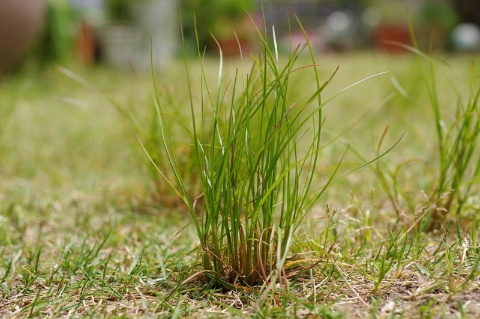

In [50]:
#url = "https://i.imgur.com/2lnWoly.jpg"
#image = Image.open(requests.get(url, stream=True).raw)
#image = Image.open('2lnWoly.jpeg')
#image = Image.open('./datasets/train/zasou/11.jpeg')
image_path=path+'/'+flist[cnt]
image = Image.open(path+'/'+flist[cnt])
cnt+=1
image

DEBUG: 480x480 検出スコアの最大値 = 0.8398
0.83983696
[0.1272662  0.83983696]
score_np: 0.83983696  zasou


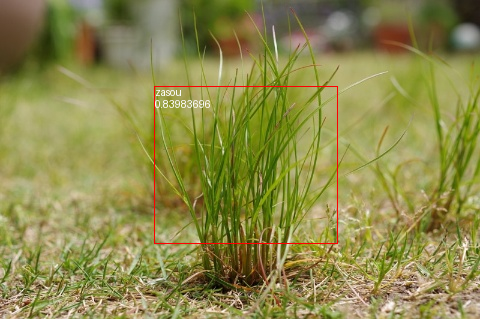

In [51]:
USE_EX_FUNC=True
if USE_EX_FUNC:
    #results = predict_old(image_path, model, image_processor,threshold=0.01)
    #results = predict_at_480_model(image_path, model, image_processor,threshold=0.01)
    results = predict_my(image_path, model, image_processor,threshold=0.01)
    #results = predict_final_check(image_path, model, image_processor,threshold=0.01)
    #print('results:',results)
else:
    inputs = image_processor(images=image, return_tensors="pt")
    outputs = model(**inputs)
    #outputs
    # convert outputs (bounding boxes and class logits) to Pascal VOC format (xmin, ymin, xmax, ymax)
    
    target_sizes = torch.tensor([image.size[::-1]])
    threshold=0.01
    results = image_processor.post_process_object_detection(outputs, threshold=threshold, target_sizes=target_sizes)[0]
    #results
    #max_score=np.max(results["scores"])
    #max_score
    #type(results["scores"])
    #print(results["scores"])
if True:
    t = results["scores"]
    n = t.detach().numpy()
    ln = len(n)
    max_score=np.max(n)
    if ln >= 3:
        mk=3
    else:
        mk=ln
    # 下位 (n-3) 個と上位3個を分ける
    top3_partition = np.partition(n, -mk)[-mk:]
    
    print(max_score)
    print(top3_partition)
    
draw = ImageDraw.Draw(image)
#max_score=0.1
for score, label, box in zip(results["scores"], results["labels"], results["boxes"]):
    score_np = score.detach().numpy()
    if score_np in top3_partition:
        if score_np >= 0.5:
            print("score_np:",score_np,'',model.config.id2label[label.item()])
            #print(type(score_np))
            #print(score_np.shape)
            box = [round(i, 2) for i in box.tolist()]
            x, y, x2, y2 = tuple(box)
            draw.rectangle((x, y, x2, y2), outline="red", width=1)
            draw.text((x, y), model.config.id2label[label.item()], fill="white")
            draw.text((x, y+12), np.array_str(score_np), fill="white")

#image.show()
image